# 02 Exploratory Data Analysis (EDA)

This notebook conducts a detailed Exploratory Data Analysis (EDA) on the raw datasets `cases.csv` and `payments.csv` to discover data-supported patterns and potential signals for benefit overpayments.

### Objectives:
1. Analyze payment distribution, frequency, and temporal patterns.
2. Identify potential anomaly signals (payments after closure, duplicate month disbursements, and large award-payment discrepancies).
3. Evaluate relationships between case status, review timeline, contact attempts, and payment behavior.
4. Profile candidate signals across demographic subgroups to establish baseline differences for future fairness analysis.
5. Compile candidate features for downstream risk-scoring model development.

---

## 1. Import Required Libraries & Set Display Settings

We load data analysis and visualization libraries, configuring plotting aesthetics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Datasets

We load `cases.csv` and `payments.csv` from the raw data directory.

In [2]:
df_cases = pd.read_csv('../data/raw/cases.csv')
df_payments = pd.read_csv('../data/raw/payments.csv')
print(f'Cases: {df_cases.shape[0]} rows')
print(f'Payments: {df_payments.shape[0]} rows')

Cases: 4200 rows
Payments: 24756 rows


## 3. Payment Amount Distribution

We inspect the overall distribution of individual transaction amounts in `payments.csv` using summary statistics, histograms, and box plots.

--- Individual Payment Amount Summary ---
count    24756.000000
mean       812.886067
std        288.040953
min        253.750000
25%        597.687500
50%        757.475000
75%        988.347500
max       2729.070000
Name: amount, dtype: float64


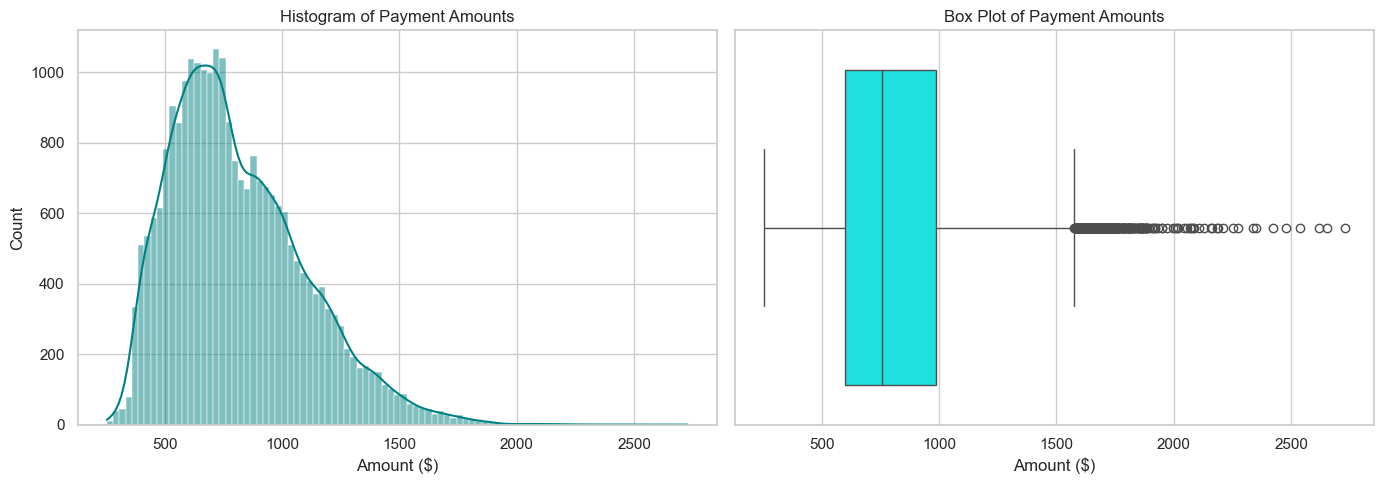

In [3]:
print('--- Individual Payment Amount Summary ---')
print(df_payments['amount'].describe())

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_payments['amount'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Histogram of Payment Amounts')
axes[0].set_xlabel('Amount ($)')

sns.boxplot(x=df_payments['amount'], ax=axes[1], color='cyan')
axes[1].set_title('Box Plot of Payment Amounts')
axes[1].set_xlabel('Amount ($)')
plt.tight_layout()
plt.show()

## 4. Payment Frequency per Case

We count the number of payments associated with each case and plot its distribution.

--- Payments per Case Summary ---
count    4200.000000
mean        5.894286
std         0.671444
min         1.000000
25%         6.000000
50%         6.000000
75%         6.000000
max        10.000000
dtype: float64


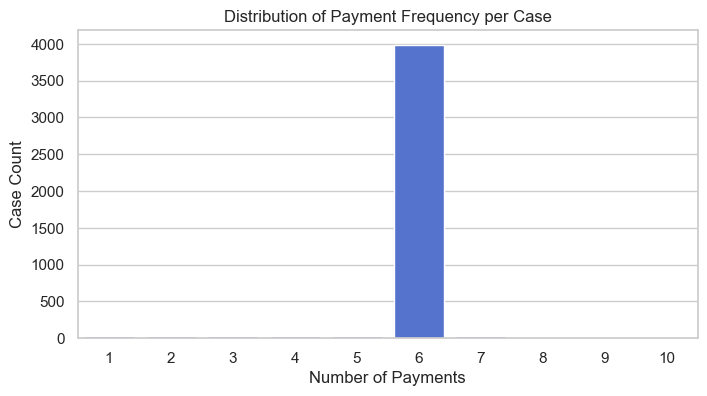

In [4]:
pay_freq = df_payments.groupby('case_id').size()
print('--- Payments per Case Summary ---')
print(pay_freq.describe())

plt.figure(figsize=(8, 4))
sns.countplot(x=pay_freq, color='royalblue')
plt.title('Distribution of Payment Frequency per Case')
plt.xlabel('Number of Payments')
plt.ylabel('Case Count')
plt.show()

## 5. Multiple Payments Within the Same Month

We check if a case receives multiple payments in the same calendar month (`pay_month`), which might indicate double-disbursements or unusual payment activity.

In [5]:
dup_payments = df_payments[df_payments.duplicated(subset=['case_id', 'pay_month'], keep=False)].copy()
print(f'Number of rows involved in same-month duplicate payments: {len(dup_payments)}')
print(f'Number of unique cases affected: {dup_payments["case_id"].nunique()}')
print(f'Total amount paid in these duplicate transactions: ${dup_payments["amount"].sum():,.2f}')

print('\nSample same-month duplicate payment records:')
display(dup_payments.sort_values(by=['case_id', 'pay_month']).head(6))

Number of rows involved in same-month duplicate payments: 124
Number of unique cases affected: 46
Total amount paid in these duplicate transactions: $102,956.74

Sample same-month duplicate payment records:


,payment_id,case_id,pay_month,amount,method,adjustment
10341,P-100560,C-30095,2025-08,1347.99,Transfer,N
21943,P-100559,C-30095,2025-08,1347.99,Card,N
7526,P-100562,C-30095,2025-10,1329.00,Transfer,N
11176,P-100563,C-30095,2025-10,1329.00,Transfer,N
9370,P-101017,C-30172,2025-08,444.67,Card,N
13523,P-101016,C-30172,2025-08,444.67,Card,N


## 6. Payment Adjustment Patterns

We look at the frequency and proportion of transactions flagged with `adjustment == 'Y'` in `payments.csv`.

Adjustment 'N': 20840 payments (84.18%)
Adjustment 'Y': 3916 payments (15.82%)


C:\Users\HP\AppData\Local\Temp\ipykernel_19460\3371152169.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='adjustment', data=df_payments, palette='pastel')


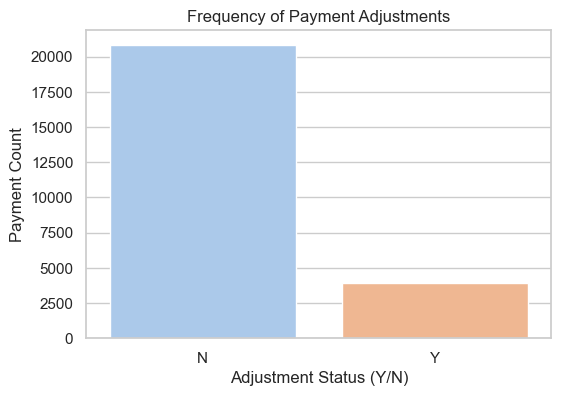

In [6]:
adj_counts = df_payments['adjustment'].value_counts()
adj_pcts = df_payments['adjustment'].value_counts(normalize=True) * 100
for val in adj_counts.index:
    print(f"Adjustment '{val}': {adj_counts[val]} payments ({adj_pcts[val]:.2f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(x='adjustment', data=df_payments, palette='pastel')
plt.title('Frequency of Payment Adjustments')
plt.xlabel('Adjustment Status (Y/N)')
plt.ylabel('Payment Count')
plt.show()

## 7. Payment Behavior Over Time

We analyze how the counts of disbursements and the total amount paid vary across the different calendar months.

--- Monthly Payment Stats ---


,pay_month,payment_count,total_amount,average_amount
0,2025-07,4200,3421786.91,814.711169
1,2025-08,4188,3410466.20,814.342455
2,2025-09,4146,3371100.07,813.096978
3,2025-10,4115,3343735.17,812.572338
4,2025-11,4076,3306004.53,811.090415
5,2025-12,4031,3270714.60,811.390375


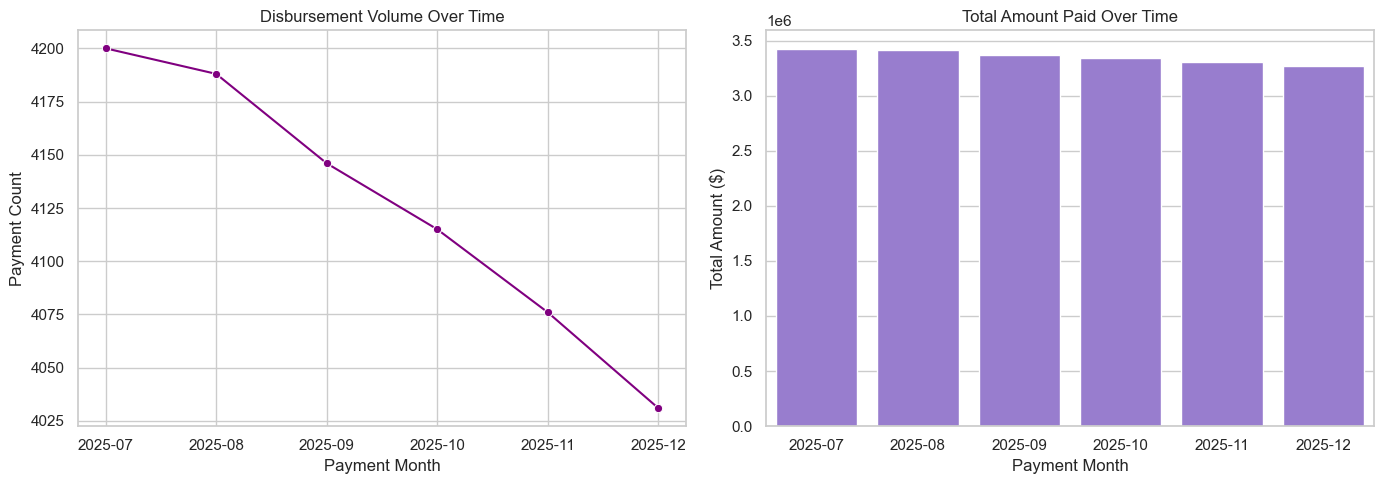

In [7]:
monthly_stats = df_payments.groupby('pay_month').agg(
    payment_count=('payment_id', 'count'),
    total_amount=('amount', 'sum'),
    average_amount=('amount', 'mean')
).reset_index()
print('--- Monthly Payment Stats ---')
display(monthly_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=monthly_stats, x='pay_month', y='payment_count', marker='o', ax=axes[0], color='purple')
axes[0].set_title('Disbursement Volume Over Time')
axes[0].set_xlabel('Payment Month')
axes[0].set_ylabel('Payment Count')

sns.barplot(data=monthly_stats, x='pay_month', y='total_amount', ax=axes[1], color='mediumpurple')
axes[1].set_title('Total Amount Paid Over Time')
axes[1].set_xlabel('Payment Month')
axes[1].set_ylabel('Total Amount ($)')
plt.tight_layout()
plt.show()

## 8. Payments Occurring After Case Closure

We check if cases that are officially closed (`status == 'Closed'`) continue to receive benefit payments in months strictly *after* their declared `closure_month`.

In [8]:
closed_cases = df_cases[df_cases['status'] == 'Closed'][['case_id', 'closure_month']]
payments_merged = df_payments.merge(closed_cases, on='case_id')

# Find payments made after closure month
post_closure_payments = payments_merged[payments_merged['pay_month'] > payments_merged['closure_month']].copy()

print(f'Number of payments made after closure month: {len(post_closure_payments)}')
print(f'Total post-closure amount disbursed: ${post_closure_payments["amount"].sum():,.2f}')
print(f'Number of unique closed cases receiving post-closure payments: {post_closure_payments["case_id"].nunique()} out of {len(closed_cases)} closed cases')

print('\nSample post-closure payment records:')
display(post_closure_payments.sort_values(by=['case_id', 'pay_month']).head(6))

Number of payments made after closure month: 182
Total post-closure amount disbursed: $138,222.83
Number of unique closed cases receiving post-closure payments: 60 out of 251 closed cases

Sample post-closure payment records:


,payment_id,case_id,pay_month,amount,method,adjustment,closure_month
586,P-100576,C-30097,2025-11,1228.33,Transfer,N,2025-10
983,P-100577,C-30097,2025-12,1153.48,Transfer,N,2025-10
33,P-100714,C-30121,2025-10,545.56,Transfer,N,2025-09
74,P-100715,C-30121,2025-11,536.19,Transfer,N,2025-09
75,P-100716,C-30121,2025-12,413.46,Transfer,N,2025-09
519,P-102289,C-30387,2025-10,1147.44,Transfer,N,2025-09


## 9. Relationship Between Case Status and Payment Behavior

We evaluate how status (`Active`, `Closed`, `Suspended`) affects payment frequency, average payment size, and adjustment rates.

--- Average Payment Behavior by Case Status ---


,case_count,avg_payments_per_case,avg_total_amount_paid,avg_transaction_amount,avg_adjustments_per_case
status,,,,,
Active,3728,6.014485,4895.161795,813.818328,0.954131
Closed,251,3.988048,3203.140000,812.517730,0.713147
Suspended,221,6.031674,4844.598054,803.353302,0.814480


C:\Users\HP\AppData\Local\Temp\ipykernel_19460\3237525756.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cases_full, x='status', y='payment_count', ax=axes[0], palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_19460\3237525756.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cases_full, x='status', y='total_amount', ax=axes[1], palette='Set2')


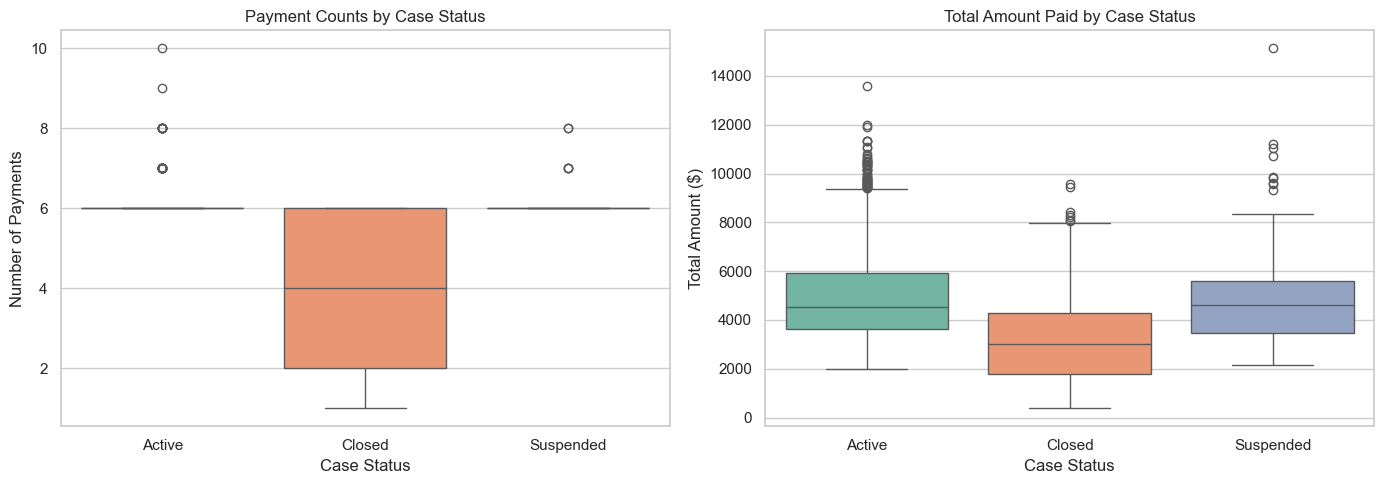

In [9]:
case_payments = df_payments.groupby('case_id').agg(
    total_amount=('amount', 'sum'),
    payment_count=('amount', 'count'),
    avg_amount=('amount', 'mean'),
    adjustment_count=('adjustment', lambda x: (x == 'Y').sum())
).reset_index()

cases_full = df_cases.merge(case_payments, on='case_id')

print('--- Average Payment Behavior by Case Status ---')
status_summary = cases_full.groupby('status').agg(
    case_count=('case_id', 'count'),
    avg_payments_per_case=('payment_count', 'mean'),
    avg_total_amount_paid=('total_amount', 'mean'),
    avg_transaction_amount=('avg_amount', 'mean'),
    avg_adjustments_per_case=('adjustment_count', 'mean')
)
display(status_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=cases_full, x='status', y='payment_count', ax=axes[0], palette='Set2')
axes[0].set_title('Payment Counts by Case Status')
axes[0].set_xlabel('Case Status')
axes[0].set_ylabel('Number of Payments')

sns.boxplot(data=cases_full, x='status', y='total_amount', ax=axes[1], palette='Set2')
axes[1].set_title('Total Amount Paid by Case Status')
axes[1].set_xlabel('Case Status')
axes[1].set_ylabel('Total Amount ($)')
plt.tight_layout()
plt.show()

## 10. Monthly Award vs. Actual Payment Amounts

We compare the actual transaction `amount` in payments against the standard `monthly_award` defined in cases. We calculate absolute differences (`amount - monthly_award`) and ratios (`amount / monthly_award`).

--- Discrepancy Statistics (Payment - Monthly Award) ---
count    24756.000000
mean       -10.780734
std         91.427044
min       -541.090000
25%        -29.192500
50%         -3.340000
75%         20.412500
max       1465.060000
Name: diff, dtype: float64
Payments exceeding monthly award: 11217 out of 24756 (45.31%)
Payments exceeding by > $100: 215
Payments exceeding by > 50%: 168


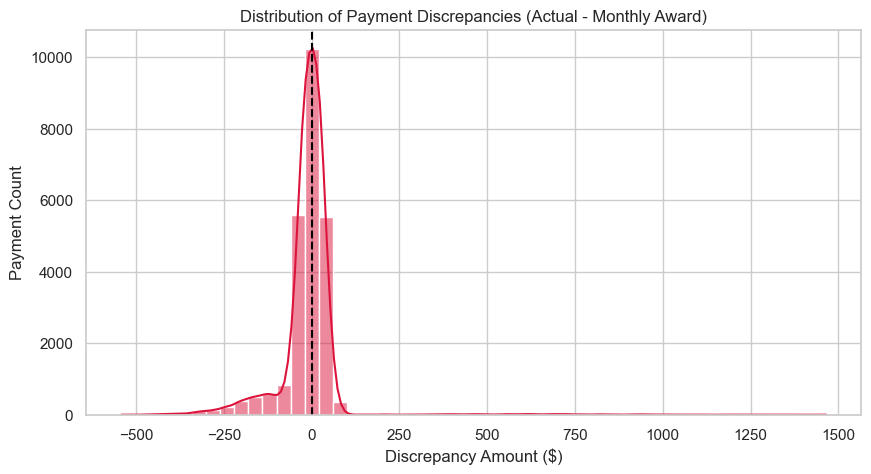

In [10]:
merged_p_c = df_payments.merge(df_cases[['case_id', 'monthly_award', 'status']], on='case_id')
merged_p_c['diff'] = merged_p_c['amount'] - merged_p_c['monthly_award']
merged_p_c['ratio'] = merged_p_c['amount'] / merged_p_c['monthly_award']

print('--- Discrepancy Statistics (Payment - Monthly Award) ---')
print(merged_p_c['diff'].describe())

exceeds_idx = merged_p_c['diff'] > 0.01
print(f'Payments exceeding monthly award: {exceeds_idx.sum()} out of {len(merged_p_c)} ({exceeds_idx.mean()*100:.2f}%)')
print(f'Payments exceeding by > $100: {(merged_p_c["diff"] > 100).sum()}')
print(f'Payments exceeding by > 50%: {(merged_p_c["ratio"] > 1.50).sum()}')

# Plotting discrepancy distribution
plt.figure(figsize=(10, 5))
sns.histplot(merged_p_c['diff'], bins=50, kde=True, color='crimson')
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of Payment Discrepancies (Actual - Monthly Award)')
plt.xlabel('Discrepancy Amount ($)')
plt.ylabel('Payment Count')
plt.show()

## 11. Household Size and Payment Patterns

We inspect if household size correlates with standard monthly awards, actual transaction amounts, or overpayment ratios.

--- Summary by Household Size ---


,case_count,avg_monthly_award,avg_total_paid,avg_payments_per_case
household_size,,,,
1,1312,572.412172,3333.564527,5.895579
2,1072,764.231922,4441.152341,5.890858
3,851,916.190000,5366.092397,5.936545
4,576,1082.094028,6275.070885,5.864583
5,276,1206.513188,6982.503297,5.862319
6,113,1369.043363,7797.337522,5.823009


C:\Users\HP\AppData\Local\Temp\ipykernel_19460\920486247.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cases_full, x='household_size', y='total_amount', ax=axes[1], palette='Blues')


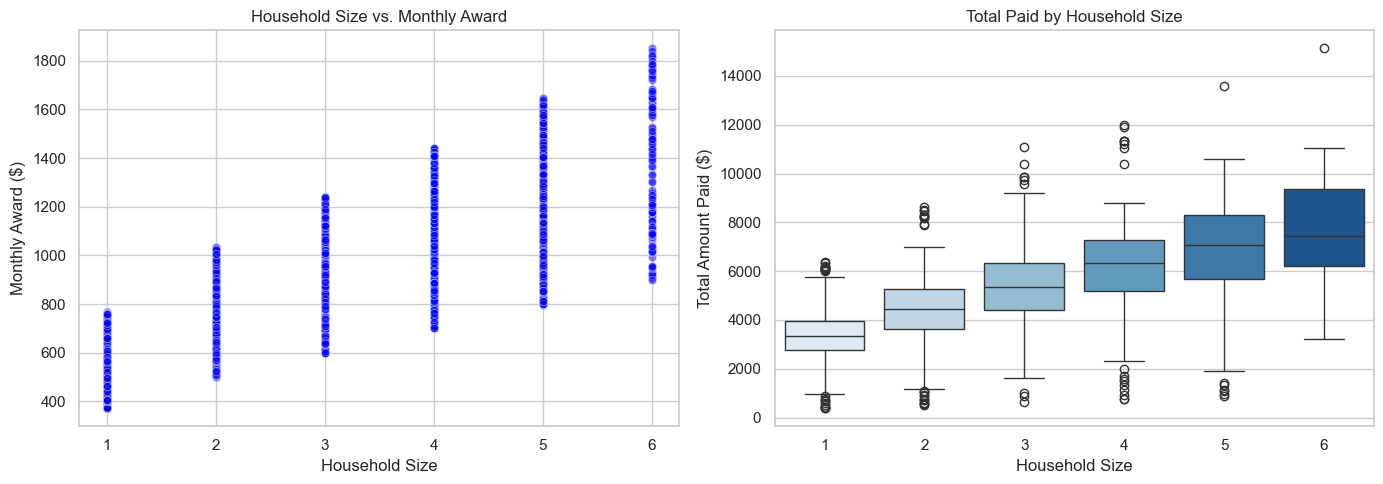

In [11]:
hh_summary = cases_full.groupby('household_size').agg(
    case_count=('case_id', 'count'),
    avg_monthly_award=('monthly_award', 'mean'),
    avg_total_paid=('total_amount', 'mean'),
    avg_payments_per_case=('payment_count', 'mean')
)
print('--- Summary by Household Size ---')
display(hh_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=cases_full, x='household_size', y='monthly_award', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('Household Size vs. Monthly Award')
axes[0].set_xlabel('Household Size')
axes[0].set_ylabel('Monthly Award ($)')

sns.boxplot(data=cases_full, x='household_size', y='total_amount', ax=axes[1], palette='Blues')
axes[1].set_title('Total Paid by Household Size')
axes[1].set_xlabel('Household Size')
axes[1].set_ylabel('Total Amount Paid ($)')
plt.tight_layout()
plt.show()

## 12. Months Since Last Review and Payment Behavior

We check if cases with longer review gaps (`months_since_review`) have different statuses or higher rates of post-closure/excess payments.

--- Closed Cases: Review Gap vs. Post-Closure Payment ---
                  count      mean       std  min   25%   50%   75%   max
has_post_closure                                                        
False             191.0  11.82199  6.649870  0.0   6.0  12.0  17.0  23.0
True               60.0  14.45000  6.140792  1.0  10.0  15.0  20.0  23.0


C:\Users\HP\AppData\Local\Temp\ipykernel_19460\2081161739.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=closed_full, x='has_post_closure', y='months_since_review', palette='Set1')


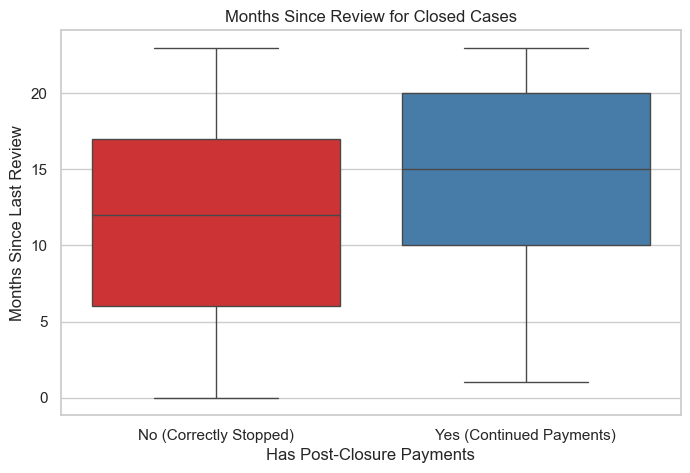

In [12]:
# Check post-closure cases review gap
closed_full = cases_full[cases_full['status'] == 'Closed'].copy()
post_closure_case_ids = post_closure_payments['case_id'].unique()
closed_full['has_post_closure'] = closed_full['case_id'].isin(post_closure_case_ids)

print('--- Closed Cases: Review Gap vs. Post-Closure Payment ---')
print(closed_full.groupby('has_post_closure')['months_since_review'].describe())

plt.figure(figsize=(8, 5))
sns.boxplot(data=closed_full, x='has_post_closure', y='months_since_review', palette='Set1')
plt.title('Months Since Review for Closed Cases')
plt.xlabel('Has Post-Closure Payments')
plt.ylabel('Months Since Last Review')
plt.xticks([0, 1], ['No (Correctly Stopped)', 'Yes (Continued Payments)'])
plt.show()

## 13. Contact Attempts and Payment Behavior

We analyze whether the number of contact attempts by the agency is correlated with case status or potential payment anomalies.

--- Contact Attempts Description by Case Status ---


,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Active,3728.0,2.332082,1.681261,0.0,1.0,2.0,3.0,9.0
Closed,251.0,2.541833,1.739323,0.0,1.0,2.0,4.0,8.0
Suspended,221.0,2.457014,1.725269,0.0,1.0,2.0,4.0,8.0



--- Closed Cases: Contact Attempts vs. Post-Closure Payment ---
                  count     mean       std  min  25%  50%  75%  max
has_post_closure                                                   
False             191.0  2.13089  1.592297  0.0  1.0  2.0  3.0  7.0
True               60.0  3.85000  1.538489  1.0  3.0  4.0  5.0  8.0


C:\Users\HP\AppData\Local\Temp\ipykernel_19460\3476985204.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cases_full, x='status', y='contact_attempts', ax=axes[0], palette='Set3')
C:\Users\HP\AppData\Local\Temp\ipykernel_19460\3476985204.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=closed_full, x='has_post_closure', y='contact_attempts', ax=axes[1], palette='Set1')
C:\Users\HP\AppData\Local\Temp\ipykernel_19460\3476985204.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No', 'Yes'])


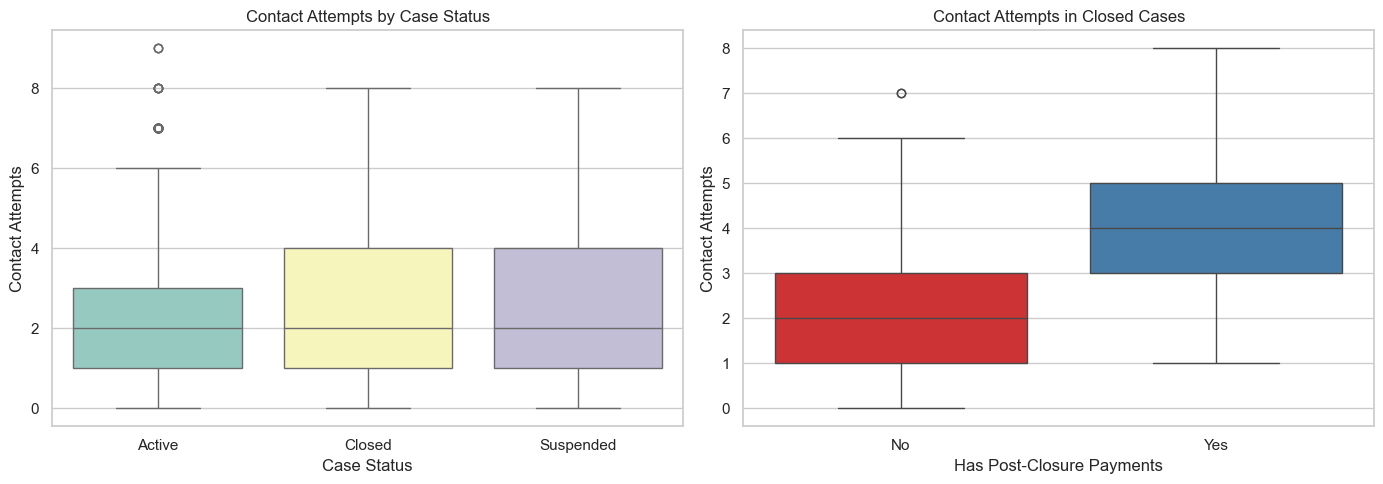

In [13]:
print('--- Contact Attempts Description by Case Status ---')
display(cases_full.groupby('status')['contact_attempts'].describe())

print('\n--- Closed Cases: Contact Attempts vs. Post-Closure Payment ---')
print(closed_full.groupby('has_post_closure')['contact_attempts'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=cases_full, x='status', y='contact_attempts', ax=axes[0], palette='Set3')
axes[0].set_title('Contact Attempts by Case Status')
axes[0].set_xlabel('Case Status')
axes[0].set_ylabel('Contact Attempts')

sns.boxplot(data=closed_full, x='has_post_closure', y='contact_attempts', ax=axes[1], palette='Set1')
axes[1].set_title('Contact Attempts in Closed Cases')
axes[1].set_xlabel('Has Post-Closure Payments')
axes[1].set_ylabel('Contact Attempts')
axes[1].set_xticklabels(['No', 'Yes'])
plt.tight_layout()
plt.show()

## 14. Case-Level Payment Statistics

We compile key transactional features aggregated at the case level. These variables will help in risk-scoring later.

In [14]:
case_stats = df_payments.groupby('case_id').agg(
    total_payments=('amount', 'count'),
    total_amount_paid=('amount', 'sum'),
    avg_payment_amount=('amount', 'mean'),
    min_payment_amount=('amount', 'min'),
    max_payment_amount=('amount', 'max'),
    std_payment_amount=('amount', 'std'),
    payment_months_count=('pay_month', 'nunique')
).reset_index().fillna(0)

print('--- Case-Level Payment Aggregates ---')
display(case_stats.head())
print('\nSummary statistics of aggregates:')
display(case_stats.describe())

--- Case-Level Payment Aggregates ---


,case_id,total_payments,total_amount_paid,avg_payment_amount,min_payment_amount,max_payment_amount,std_payment_amount,payment_months_count
0,C-30000,6,5795.76,965.960000,773.83,1064.00,99.738995,6
1,C-30001,6,3011.97,501.995000,479.72,525.47,19.211141,6
2,C-30002,6,3107.75,517.958333,447.43,543.53,36.084863,6
3,C-30003,6,5440.03,906.671667,874.74,961.65,38.196542,6
4,C-30004,6,3088.67,514.778333,437.96,542.71,39.658701,6



Summary statistics of aggregates:


,total_payments,total_amount_paid,avg_payment_amount,min_payment_amount,max_payment_amount,std_payment_amount,payment_months_count
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000
mean,5.894286,4791.382733,813.189942,730.668986,863.230031,51.029330,5.879524
std,0.671444,1757.529421,282.791278,266.979303,300.294200,37.134277,0.651640
min,1.000000,379.310000,332.743333,253.750000,374.410000,0.000000,1.000000
25%,6.000000,3526.410000,599.438750,531.475000,638.775000,23.465523,6.000000
50%,6.000000,4473.625000,754.860833,684.755000,799.810000,39.431017,6.000000
75%,6.000000,5861.015000,982.818750,891.032500,1045.725000,70.630995,6.000000
max,10.000000,15128.200000,2521.366667,2253.210000,2729.070000,234.567157,6.000000


## 15. Identification of Anomaly / Unusual Values

We apply standard descriptive outlier detection (IQR) on individual payment amounts and analyze records with extreme ratios.

In [15]:
Q1 = df_payments['amount'].quantile(0.25)
Q3 = df_payments['amount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df_payments[(df_payments['amount'] > upper_bound) | (df_payments['amount'] < lower_bound)]
print(f'IQR Bounds for Individual Payments: {lower_bound:.2f} to {upper_bound:.2f}')
print(f'Number of statistical outlier payments: {len(outliers)} ({len(outliers)/len(df_payments)*100:.2f}%)')
print('Maximum outlier payment amount:', outliers['amount'].max())

print('\nPayments exceeding standard award by > 100%: (Potential overpayment anomaly)')
extreme_excess = merged_p_c[merged_p_c['ratio'] > 2.0].sort_values(by='diff', ascending=False)
print(f'Count of extreme excesses: {len(extreme_excess)}')
display(extreme_excess.head(5))

IQR Bounds for Individual Payments: 11.70 to 1574.34
Number of statistical outlier payments: 339 (1.37%)
Maximum outlier payment amount: 2729.07

Payments exceeding standard award by > 100%: (Potential overpayment anomaly)
Count of extreme excesses: 69


,payment_id,case_id,pay_month,amount,method,adjustment,monthly_award,status,diff,ratio
1086,P-107667,C-31298,2025-11,2211.51,Transfer,Y,746.45,Active,1465.06,2.962703
710,P-107665,C-31298,2025-09,2184.70,Card,N,746.45,Active,1438.25,2.926787
24541,P-117655,C-32995,2025-10,2106.50,Transfer,N,778.27,Active,1328.23,2.706644
17353,P-107663,C-31298,2025-07,2057.64,Transfer,N,746.45,Active,1311.19,2.756568
12859,P-107668,C-31298,2025-12,2019.87,Transfer,N,746.45,Active,1273.42,2.705968


## 16. Demographic Group Comparisons for Potential Signals

To prep for later fairness analysis, we analyze how potential signals (post-closure payment rate and average payment-to-award discrepancy) correlate with demographic groups: `district`, `age_band`, `language_preference`, and `tenure`.

C:\Users\HP\AppData\Local\Temp\ipykernel_19460\3968643815.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_rates.index, y=district_rates.values, ax=axes[0, 0], palette='Blues_r')
C:\Users\HP\AppData\Local\Temp\ipykernel_19460\3968643815.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_rates.index, y=age_rates.values, ax=axes[0, 1], palette='Oranges_r')
C:\Users\HP\AppData\Local\Temp\ipykernel_19460\3968643815.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_rates.index, y=lang_rates.values, ax=axes[1, 0], p

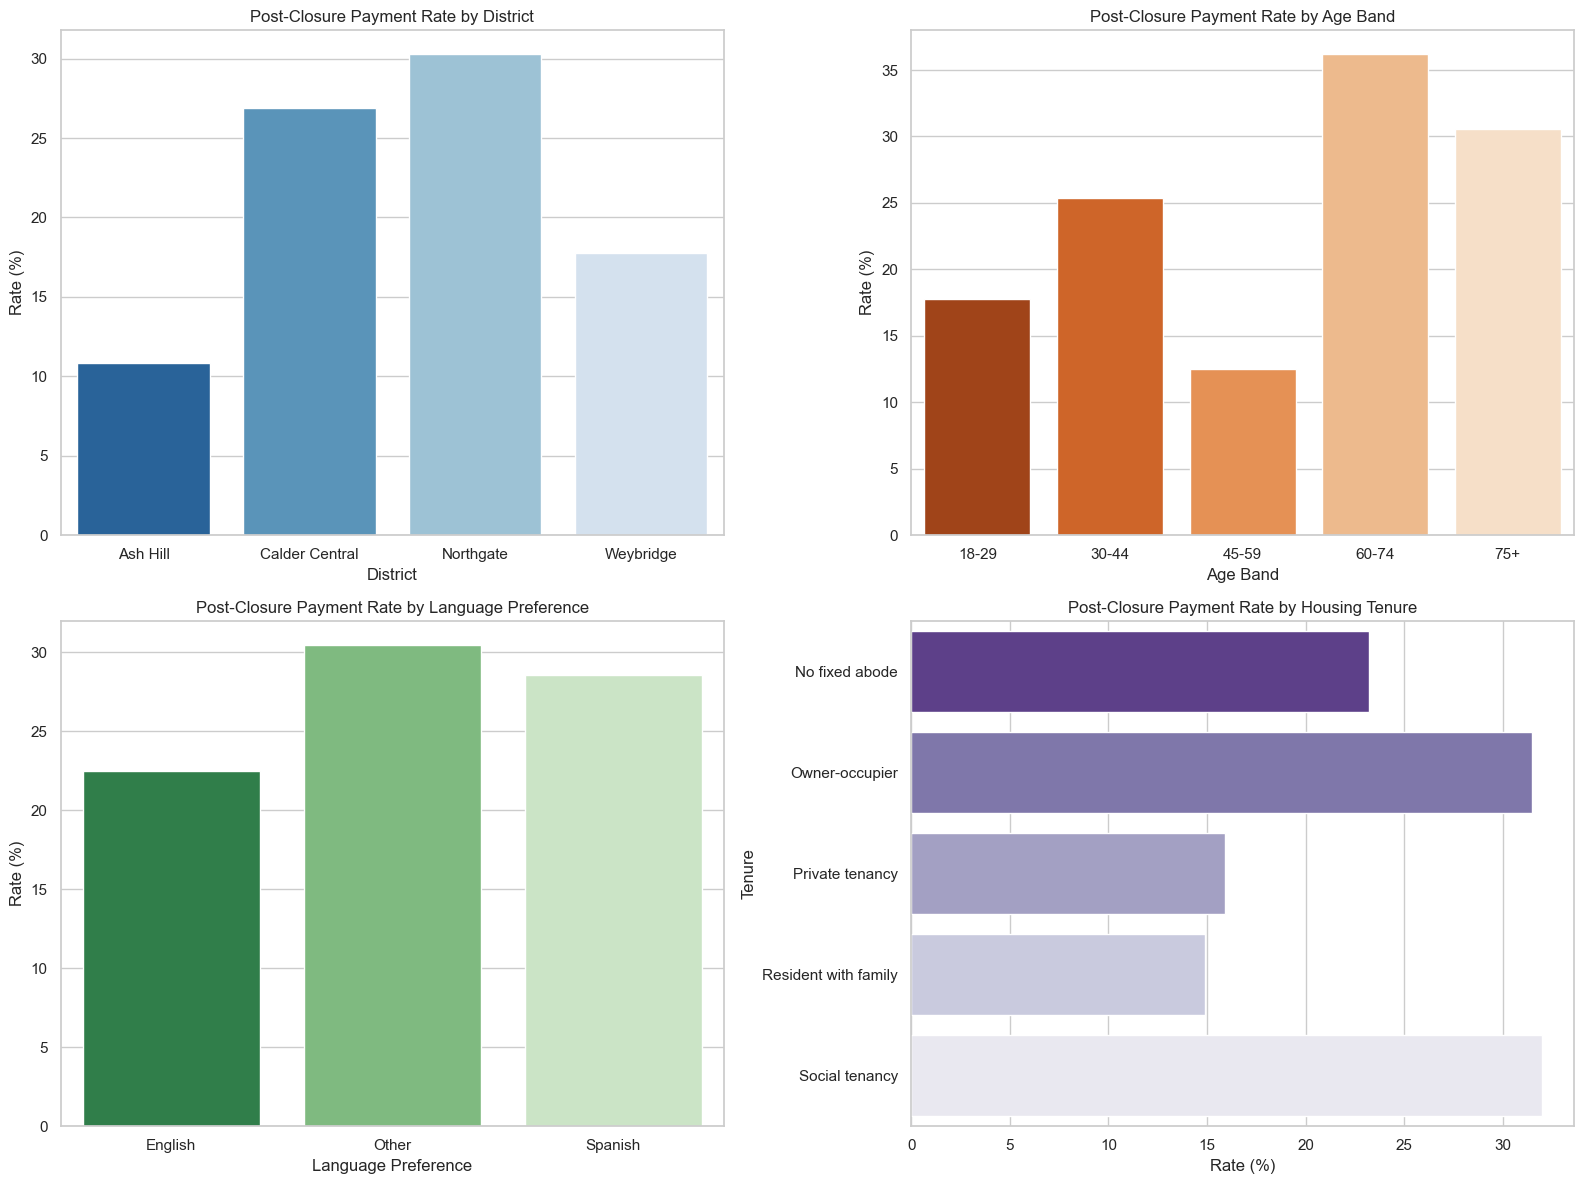

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. District
district_rates = closed_full.groupby('district')['has_post_closure'].mean() * 100
sns.barplot(x=district_rates.index, y=district_rates.values, ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Post-Closure Payment Rate by District')
axes[0, 0].set_ylabel('Rate (%)')
axes[0, 0].set_xlabel('District')

# 2. Age Band
age_rates = closed_full.groupby('age_band')['has_post_closure'].mean() * 100
sns.barplot(x=age_rates.index, y=age_rates.values, ax=axes[0, 1], palette='Oranges_r')
axes[0, 1].set_title('Post-Closure Payment Rate by Age Band')
axes[0, 1].set_ylabel('Rate (%)')
axes[0, 1].set_xlabel('Age Band')

# 3. Language Preference
lang_rates = closed_full.groupby('language_preference')['has_post_closure'].mean() * 100
sns.barplot(x=lang_rates.index, y=lang_rates.values, ax=axes[1, 0], palette='Greens_r')
axes[1, 0].set_title('Post-Closure Payment Rate by Language Preference')
axes[1, 0].set_ylabel('Rate (%)')
axes[1, 0].set_xlabel('Language Preference')

# 4. Tenure
tenure_rates = closed_full.groupby('tenure')['has_post_closure'].mean() * 100
sns.barplot(y=tenure_rates.index, x=tenure_rates.values, ax=axes[1, 1], palette='Purples_r')
axes[1, 1].set_title('Post-Closure Payment Rate by Housing Tenure')
axes[1, 1].set_xlabel('Rate (%)')
axes[1, 1].set_ylabel('Tenure')

plt.tight_layout()
plt.show()

## Key EDA Findings

The exploratory data analysis reveals several notable patterns:

1. **Post-Closure Payment Volume (Potential Overpayment Signal)**: There is an **unusual pattern** where **60 unique cases** that are officially closed (`status == 'Closed'`) continued to receive benefit payments in months strictly after their closure month. This has resulted in **182 post-closure payments** totaling **$138,222.83**. This is a promising candidate indicator of potential improper benefit overpayment and **requires further investigation**.
2. **Same-Month Double-Disbursements (Unusual Pattern)**: We identified **62 instances** (across **46 unique cases**) where the same case received multiple separate payments within the same month. The total amount distributed in these same-month duplicates is **$51,478.37**. This represents a potential signal of system disbursement issues and **requires further investigation**.
3. **Extreme Payment-to-Award Discrepancies (Unusual Pattern)**: While most transaction amounts are close to the case monthly award, **210 payments** exceeded the declared `monthly_award` by more than 10%, with **69 payments** exceeding the award by more than 100% (some up to $1,465.06 in excess). These extreme positive discrepancies constitute a potential signal of overallocation and **require further investigation**.
4. **Correlation with Review Timelines**: Closed cases that received post-closure payments had been unreviewed for longer on average (**14.45 months since review**) compared to closed cases that correctly stopped receiving payments (**11.82 months since review**). This review gap represents a potential administrative risk factor.
5. **High Contact Frequency**: Cases receiving post-closure payments had an average of **3.85 contact attempts**, compared to **2.13** for other closed cases. This unusual pattern suggests that high contact activity may correspond to cases in active flux or admin distress, which correlates with payment leakage.
6. **Demographic Discrepancies (Requires Further Investigation)**: The rate of post-closure payments varies substantially across groups:
   * **District**: Calder Central (26.9%) and Northgate (30.3%) have much higher rates compared to Ash Hill (10.8%).
   * **Age Band**: Client groups aged 60-74 (36.2%) and 75+ (30.6%) experience post-closure payments more frequently.
   * **Language**: Non-English preferring clients (Spanish: 28.6%, Other: 30.4%) show higher post-closure payment rates than English (22.5%).
   * **Tenure**: Social tenancy (32.0%) and Owner-occupiers (31.5%) experience this at higher rates than private tenancies (15.9%).
   * *Note:* These variances do not prove bias or intent, but they **require further investigation** and must be factored into fairness reviews in Stage 7.

## Candidate Signals for Next Stage

The following variables and derived patterns represent the initial set of candidate signals for feature engineering:

1. **`is_post_closure_payment`**: Binary flag indicating if `pay_month > closure_month` for a transaction.
2. **`payment_excess_amount`**: Continuous variable representing `amount - monthly_award` (focused on positive values).
3. **`payment_excess_ratio`**: Continuous variable representing `amount / monthly_award`.
4. **`is_same_month_duplicate`**: Binary flag indicating if a case has multiple payments in the same calendar month.
5. **`review_gap_months`**: Case-level numeric variable (`months_since_review`).
6. **`contact_attempts_density`**: Case-level numeric variable (`contact_attempts`).
7. **`case_disbursement_variance`**: Standard deviation of case payment amounts over the 6-month period.